In [18]:
from Environment import evaluate_performance
from Environment import plot_HVAC_results
from pathlib import Path
import os
import numpy as np
import matplotlib.pyplot as plt

Tuning of policy

In [ ]:
policy_file = "dummy_policy_20" # TODO replace with your policy file
results = evaluate_performance(policy_file)
print(f"Average daily cost over {len(results)} days: {np.mean([res['cost_total'] for res in results]):.2f} €")
plot_HVAC_results(results[0])
plt.show()

Evaluating policy: dummy_policy_20
Average daily cost over 100 days: 973.87 €


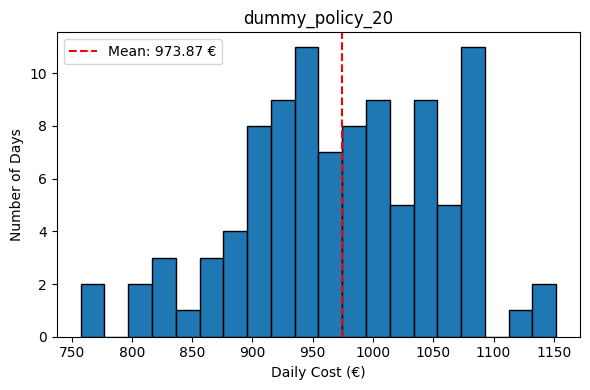

In [ ]:
mdp_policies = [
    "dummy_policy_20",
    # "lookahead_policy_20",
    # "spTwoStage_policy_20",
    # "sp_policy_20",
    # "adp_policy_20",
    # "hybrid_policy_20"
    ]

# Data files
DIR = Path(os.getcwd())
price_file = DIR / "v2_PriceData.csv"
occupancy1_file = DIR / "OccupancyRoom1.csv"
occupancy2_file = DIR / "OccupancyRoom2.csv"

# TODO implememt OIH model here and evaluate the performance of the OIH policy

fig, axes = plt.subplots(1, len(mdp_policies), figsize=(6 * len(mdp_policies), 4), squeeze=False)

for i, mdp_policy in enumerate(mdp_policies):
    print(f"Evaluating policy: {mdp_policy}")
    results = evaluate_performance(mdp_policy, 100, file_price_data=price_file, file_occupancy1=occupancy1_file, file_occupancy2=occupancy2_file)
    daily_costs = [res['cost_total'] for res in results]
    avg_cost = np.mean(daily_costs)
    print(f"Average daily cost over {len(results)} days: {avg_cost:.2f} €")

    ax = axes[0][i]
    ax.hist(daily_costs, bins=20, edgecolor='black')
    ax.axvline(avg_cost, color='red', linestyle='--', label=f'Mean: {avg_cost:.2f} €')
    ax.set_title(mdp_policy)
    ax.set_xlabel("Daily Cost (€)")
    ax.set_ylabel("Number of Days")
    ax.legend()

plt.tight_layout()
plt.show()